# Post-infusion hypnodensity, subjective intensity and entity reports

This notebook consolidates the two post-infusion-only analyses that were developed separately in notebooks 06 (subjective intensity) and 07 (entity presence). Both ask the same question on the same scale: **within the DMT infusion period, how does the EEG hypnodensity vary relative to each electrode's own post-infusion mean?** There is no comparison against the pre-infusion baseline and no comparison against placebo.

For every `subject × electrode × response`, the paired post-infusion values are standardized across only that electrode's available paired ratings:

`z = (paired value − mean of paired post-infusion values) / SD of paired post-infusion values`

The reference is therefore the DMT-period mean itself.

**Unit of analysis.** Each rating is paired with ~32 electrodes, but those electrodes are not independent observations of the effect: the within-electrode z-score removes electrode main effects entirely, so the only clustering left is at the rating level. Fitting at the electrode level would therefore treat ~32 correlated rows as independent and overstate precision. The models below are fitted on **electrode-averaged ratings**, one observation per `subject × timepoint`, with a subject random intercept.

Responses are Wake, N1 and REM probabilities plus the normalized hypnodensity entropy, from the `gssc` stager.


## 1. Imports and fixed analysis settings

The worksheet columns `D:O` are assigned the sampling-time mapping used for the paired EEG windows: `0, 1, 2, 3, 4, 6, 10, 14, 18, 22, 26, 30` minutes. A rating at time *t* is paired with the overlap-weighted EEG probability in the 60 seconds ending at *t* after the 14-minute recording offset. The same pairing serves both the `Intensity` and the `Entities` worksheets.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'outputs').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

RATINGS_PATH = Path('/home/rherzoga/Documentos/Projects/Timmerman/data/ES_ratings.xlsx')
RUN_NAME = 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1'
RUN_ROOT = PROJECT_ROOT / 'outputs' / RUN_NAME
RECORDINGS_DIR = RUN_ROOT / 'recordings'
OUTPUT_DIR = RUN_ROOT.parent / 'postinfusion_zscore_lme_analysis_gssc_v1'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TIMEPOINTS_MIN = (0, 1, 2, 3, 4, 6, 10, 14, 18, 22, 26, 30)
EEG_OFFSET_SECONDS = 14 * 60
WINDOW_SECONDS = 60
STAGER = 'gssc'
PROBABILITIES = ('prob_W', 'prob_N1', 'prob_N2', 'prob_N3', 'prob_R')
RESPONSES = ('prob_W', 'prob_N1', 'prob_R', 'entropy')
RESPONSE_LABELS = {'prob_W': 'Wake', 'prob_N1': 'N1', 'prob_R': 'REM', 'entropy': 'Entropy'}
ENTITY_LABELS = {0: 'No entity', 1: 'Entity'}
INTENSITY_FORMULA = 'response ~ intensity'
ENTITY_FORMULA = 'response ~ entity'

plt.rcParams.update({
    'font.family': 'Liberation Sans', 'font.sans-serif': ['Liberation Sans'],
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

assert len(TIMEPOINTS_MIN) == 12
display({
    'ratings_file': str(RATINGS_PATH), 'recordings': str(RECORDINGS_DIR),
    'intensity_formula': INTENSITY_FORMULA, 'entity_formula': ENTITY_FORMULA,
})

{'ratings_file': '/home/rherzoga/Documentos/Projects/Timmerman/data/ES_ratings.xlsx',
 'recordings': '/home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1/recordings',
 'intensity_formula': 'response ~ intensity',
 'entity_formula': 'response ~ entity'}

## 2. Ratings and EEG pairing

Both worksheets are read with the same `D:O` encoding. Intensity ratings are kept whenever they are numeric; for entities only `0` (absence) and `1` (presence) are analysed, so the ambiguous value `0.5`, text entries and missing values are excluded.

The pairing uses the overlap-weighted 60-second EEG window ending at each rating time, and keeps the raw probabilities on their natural scale. No baseline centering is applied: the z-scoring in section 3 is taken directly over these paired post-infusion probabilities, and a subject-electrode baseline constant would be removed by that standardization anyway.

In [2]:
subject_column = pd.read_excel(RATINGS_PATH, sheet_name='Intensity', header=None, usecols='A').iloc[:, 0]


def read_ratings(sheet_name, value_name):
    '''Melt the D:O block of one worksheet into long `subject × timepoint` ratings.'''
    wide = pd.read_excel(RATINGS_PATH, sheet_name=sheet_name, header=None, usecols='D:O')
    wide.columns = TIMEPOINTS_MIN
    wide.insert(0, 'subject', pd.read_excel(
        RATINGS_PATH, sheet_name=sheet_name, header=None, usecols='A').iloc[:, 0].astype(str))
    long = wide.melt('subject', var_name='timepoint', value_name=value_name)
    long['timepoint'] = long['timepoint'].astype(int)
    long[value_name] = pd.to_numeric(long[value_name], errors='coerce')
    return long


intensity_ratings = read_ratings('Intensity', 'intensity').dropna(subset=['intensity']).reset_index(drop=True)

entity_ratings = read_ratings('Entities', 'entity')
entity_ratings = entity_ratings.loc[entity_ratings['entity'].isin([0, 1])].copy()
entity_ratings['entity'] = entity_ratings['entity'].astype(int)

files = sorted(RECORDINGS_DIR.glob('*_hypnodensities.parquet'))
if not files:
    raise FileNotFoundError(f'No persisted hypnodensity files found in {RECORDINGS_DIR}.')
eeg = pd.concat([pd.read_parquet(file) for file in files], ignore_index=True)
eeg = eeg.loc[
    eeg['condition'].astype(str).eq('DMT') & eeg['stager'].astype(str).eq(STAGER)
].copy()
dmt_subjects = eeg['subject'].astype(str).unique()


def normalized_entropy(values):
    '''Shannon entropy of the five-state hypnodensity, normalized to [0, 1].'''
    values = np.asarray(values, dtype=float)
    return -np.where(values > 0, values * np.log(values), 0.0).sum() / np.log(len(PROBABILITIES))


eeg['entropy'] = eeg[list(PROBABILITIES)].apply(normalized_entropy, axis=1)


def pair_ratings_with_eeg(ratings, predictor):
    '''Overlap-weighted average of the 60-s EEG window ending at each rating time.

    Returns one row per `subject × timepoint × electrode`, on the raw probability
    scale, plus a per-rating coverage table.
    '''
    ratings = ratings.loc[ratings['subject'].isin(dmt_subjects)].copy()
    ratings['eeg_window_end'] = EEG_OFFSET_SECONDS + ratings['timepoint'] * 60
    ratings['eeg_window_start'] = ratings['eeg_window_end'] - WINDOW_SECONDS

    window_rows, coverage_rows = [], []
    for rating in ratings.itertuples(index=False):
        candidates = eeg.loc[
            eeg['subject'].astype(str).eq(rating.subject)
            & eeg['absolute_start'].lt(rating.eeg_window_end)
            & eeg['absolute_end'].gt(rating.eeg_window_start)
        ].copy()
        candidates['overlap_seconds'] = (
            np.minimum(candidates['absolute_end'], rating.eeg_window_end)
            - np.maximum(candidates['absolute_start'], rating.eeg_window_start)
        )
        candidates = candidates.loc[candidates['overlap_seconds'].gt(0)]
        coverage_rows.append({
            'subject': rating.subject, 'timepoint': rating.timepoint,
            predictor: getattr(rating, predictor),
            'n_overlapping_epochs': len(candidates),
            'overlap_seconds_all_electrodes': candidates['overlap_seconds'].sum(),
            'n_electrodes_with_overlap': candidates['electrode'].nunique(),
        })
        for electrode, epochs in candidates.groupby('electrode', observed=True):
            weighted = np.average(epochs[list(RESPONSES)], axis=0, weights=epochs['overlap_seconds'])
            window_rows.append({
                'subject': rating.subject, 'timepoint': rating.timepoint,
                predictor: getattr(rating, predictor), 'electrode': electrode,
                'prob_W': weighted[0], 'prob_N1': weighted[1],
                'prob_R': weighted[2], 'entropy': weighted[3],
            })

    paired = pd.DataFrame(window_rows)
    coverage = pd.DataFrame(coverage_rows)
    coverage['has_valid_eeg_pair'] = coverage.set_index(['subject', 'timepoint']).index.isin(
        paired[['subject', 'timepoint']].drop_duplicates().set_index(['subject', 'timepoint']).index
    )
    return paired, coverage


intensity_electrode_raw, intensity_coverage = pair_ratings_with_eeg(intensity_ratings, 'intensity')
entity_electrode_raw, entity_coverage = pair_ratings_with_eeg(entity_ratings, 'entity')

intensity_coverage.to_csv(OUTPUT_DIR / 'intensity_eeg_coverage.csv', index=False)
entity_coverage.to_csv(OUTPUT_DIR / 'entity_eeg_coverage.csv', index=False)

entity_coverage_by_timepoint = (entity_coverage.groupby(['timepoint', 'entity'], observed=True)
    .agg(ratings_in_sheet=('subject', 'size'), valid_ratings=('has_valid_eeg_pair', 'sum'),
         valid_subjects=('subject', lambda x: x[entity_coverage.loc[x.index, 'has_valid_eeg_pair']].nunique()))
    .reset_index())
entity_coverage_by_timepoint.to_csv(OUTPUT_DIR / 'entity_eeg_coverage_by_timepoint.csv', index=False)

intensity_coverage_by_timepoint = (intensity_coverage.groupby('timepoint', observed=True)
    .agg(ratings_in_sheet=('subject', 'size'), valid_ratings=('has_valid_eeg_pair', 'sum'),
         valid_subjects=('subject', lambda x: x[intensity_coverage.loc[x.index, 'has_valid_eeg_pair']].nunique()),
         median_overlap_seconds_all_electrodes=('overlap_seconds_all_electrodes', 'median'))
    .reset_index())
intensity_coverage_by_timepoint.to_csv(OUTPUT_DIR / 'intensity_eeg_coverage_by_timepoint.csv', index=False)

display(intensity_coverage_by_timepoint)
display(entity_coverage_by_timepoint)
display({
    'intensity valid paired ratings': int(intensity_coverage['has_valid_eeg_pair'].sum()),
    'intensity valid subjects': intensity_electrode_raw['subject'].nunique(),
    'intensity electrode-level observations': len(intensity_electrode_raw),
    'entity valid paired ratings': int(entity_coverage['has_valid_eeg_pair'].sum()),
    'entity valid subjects': entity_electrode_raw['subject'].nunique(),
    'entity electrode-level observations': len(entity_electrode_raw),
})

,timepoint,ratings_in_sheet,valid_ratings,valid_subjects,median_overlap_seconds_all_electrodes
0,0,16,12,12,959.936
1,1,16,1,1,0.000
2,2,16,1,1,0.000
3,3,16,2,2,0.000
4,4,16,3,3,0.000
5,6,16,2,2,0.000
6,10,16,4,4,0.000
7,14,16,6,6,0.000
8,18,16,4,4,0.000
9,22,16,3,3,0.000


,timepoint,entity,ratings_in_sheet,valid_ratings,valid_subjects
0,0,0,18,13,13
1,1,0,12,1,1
2,1,1,6,0,0
3,2,0,10,1,1
4,2,1,8,1,1
5,3,0,8,0,0
6,3,1,10,2,2
7,4,0,7,1,1
8,4,1,10,2,2
9,6,0,10,2,2


{'intensity valid paired ratings': 46,
 'intensity valid subjects': 14,
 'intensity electrode-level observations': 1472,
 'entity valid paired ratings': 52,
 'entity valid subjects': 16,
 'entity electrode-level observations': 1664}

## 3. Post-infusion-only z-scores

For each `subject × electrode × response`, the paired post-infusion values are standardized across only that electrode's available paired ratings. A zero or unavailable within-electrode SD is left missing and excluded only for that response's model and plot. Subjects contributing a single paired rating therefore drop out, because a within-electrode SD is undefined for them.

Electrodes are then averaged within each rating, giving one observation per `subject × timepoint`. This averaged table is what both the models and the figures use.

Note that the two analyses standardize over slightly different sets of ratings: each uses the paired ratings that are valid on its own worksheet.


In [3]:
def postinfusion_zscore(paired, predictor):
    '''Standardize each subject-electrode across only its paired post-infusion ratings.'''
    z_scored = paired[['subject', 'timepoint', 'electrode', predictor]].copy()
    for response_name in RESPONSES:
        grouped = paired.groupby(['subject', 'electrode'], observed=True)[response_name]
        post_mean = grouped.transform('mean')
        post_sd = grouped.transform('std')
        z_scored[response_name] = (paired[response_name] - post_mean) / post_sd.replace(0, np.nan)
    return z_scored


def average_electrodes(z_scored, predictor):
    '''Collapse electrodes within each rating: one row per `subject x timepoint`.'''
    return (z_scored.groupby(['subject', 'timepoint', predictor], observed=True)[list(RESPONSES)]
            .mean().reset_index())


intensity_electrode_post_z = postinfusion_zscore(intensity_electrode_raw, 'intensity')
entity_electrode_post_z = postinfusion_zscore(entity_electrode_raw, 'entity')

intensity_rating_post_z = average_electrodes(intensity_electrode_post_z, 'intensity')
entity_rating_post_z = average_electrodes(entity_electrode_post_z, 'entity')

intensity_electrode_post_z.to_parquet(
    OUTPUT_DIR / 'intensity_electrode_raw_probability_postinfusion_zscore.parquet', index=False)
entity_electrode_post_z.to_parquet(
    OUTPUT_DIR / 'entity_electrode_raw_probability_postinfusion_zscore.parquet', index=False)
intensity_rating_post_z.to_csv(
    OUTPUT_DIR / 'intensity_rating_postinfusion_zscore_means.csv', index=False)
entity_rating_post_z.to_csv(
    OUTPUT_DIR / 'entity_rating_postinfusion_zscore_means.csv', index=False)

display({
    'intensity electrode-level rows': len(intensity_electrode_post_z),
    'intensity averaged ratings': len(intensity_rating_post_z.dropna(subset=list(RESPONSES))),
    'intensity subjects': intensity_rating_post_z.dropna(subset=list(RESPONSES))['subject'].nunique(),
    'entity electrode-level rows': len(entity_electrode_post_z),
    'entity averaged ratings': len(entity_rating_post_z.dropna(subset=list(RESPONSES))),
    'entity subjects': entity_rating_post_z.dropna(subset=list(RESPONSES))['subject'].nunique(),
})
display(intensity_rating_post_z[list(RESPONSES)].describe().round(4))
display(entity_rating_post_z[list(RESPONSES)].describe().round(4))


{'intensity electrode-level rows': 1472,
 'intensity averaged ratings': 43,
 'intensity subjects': 11,
 'entity electrode-level rows': 1664,
 'entity averaged ratings': 48,
 'entity subjects': 12}

,prob_W,prob_N1,prob_R,entropy
count,43.0000,43.0000,43.0000,43.0000
mean,0.0000,-0.0000,0.0000,-0.0000
std,0.6424,0.6231,0.6083,0.5414
min,-1.2434,-0.8250,-0.9090,-0.8181
25%,-0.4991,-0.6016,-0.5674,-0.3850
50%,0.1326,-0.0961,0.0083,-0.0079
75%,0.6251,0.5204,0.4761,0.3775
max,0.8728,1.2090,1.5663,1.2416


,prob_W,prob_N1,prob_R,entropy
count,48.0000,48.0000,48.0000,48.0000
mean,0.0000,0.0000,0.0000,-0.0000
std,0.6527,0.6298,0.6398,0.5730
min,-1.2434,-0.8686,-0.9090,-1.1389
25%,-0.4841,-0.5966,-0.5634,-0.4264
50%,0.1174,-0.0708,-0.0763,0.0005
75%,0.6062,0.5134,0.4703,0.4021
max,0.8859,1.2090,1.6990,1.2416


## 4. Post-infusion-only z-score LME models

Both families fit `z-score ~ predictor` with a subject random intercept, on the **electrode-averaged ratings** from section 3. One observation per `subject × timepoint`.

Electrode main effects were removed by the within-electrode z-score, so no electrode variance component is identifiable; averaging electrodes is what keeps the rating, rather than the electrode, as the unit of replication.

The Benjamini–Hochberg FDR correction is applied **separately within each family** of four responses.


In [4]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(p_values.shape, np.nan)
    finite = np.flatnonzero(np.isfinite(p_values))
    if finite.size:
        ordered = finite[np.argsort(p_values[finite])]
        ranked = p_values[ordered] * finite.size / np.arange(1, finite.size + 1)
        adjusted[ordered] = np.minimum.accumulate(ranked[::-1])[::-1].clip(max=1)
    return adjusted


def fit_post_z_lme(model_data, formula):
    # One row per rating: electrodes were averaged in section 3.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fit = smf.mixedlm(
            formula, data=model_data, groups=model_data['subject'], re_formula='1',
        ).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
    return fit, 'lbfgs'


def run_post_z_models(rating_level, predictor, formula, term_label):
    '''Fit one post-infusion z-score LME per response and collect the predictor term.'''
    model_rows = []
    for response_name in RESPONSES:
        model_data = (rating_level[['subject', 'timepoint', predictor, response_name]]
                      .dropna().rename(columns={response_name: 'response'}))
        fit, optimizer = fit_post_z_lme(model_data, formula)
        ci = fit.conf_int().loc[predictor]
        row = {
            'response': RESPONSE_LABELS[response_name], 'outcome_column': response_name,
            'term': term_label, 'beta': float(fit.fe_params[predictor]),
            'standard_error': float(fit.bse_fe[predictor]),
            'ci95_low': float(ci.iloc[0]), 'ci95_high': float(ci.iloc[1]),
            'z_value': float(fit.tvalues[predictor]), 'p_value': float(fit.pvalues[predictor]),
            'n_subjects': int(model_data['subject'].nunique()),
            'n_paired_ratings': int(len(model_data)),
        }
        if predictor == 'entity':
            row['n_entity_present_ratings'] = int(model_data['entity'].eq(1).sum())
            row['n_entity_absent_ratings'] = int(model_data['entity'].eq(0).sum())
            row['n_subjects_with_both_states'] = int(
                model_data.groupby('subject')['entity'].nunique().eq(2).sum())
        row['converged'] = bool(fit.converged)
        row['optimizer'] = optimizer
        model_rows.append(row)
    results = pd.DataFrame(model_rows)
    results['p_fdr_bh'] = benjamini_hochberg(results['p_value'])
    return results


intensity_post_z_lme_results = run_post_z_models(
    intensity_rating_post_z, 'intensity', INTENSITY_FORMULA, 'Per unit of subjective intensity')
entity_post_z_lme_results = run_post_z_models(
    entity_rating_post_z, 'entity', ENTITY_FORMULA, 'Entity present minus absent')

intensity_post_z_lme_results.to_csv(
    OUTPUT_DIR / 'intensity_hypnodensity_lme_results_postinfusion_zscore.csv', index=False)
entity_post_z_lme_results.to_csv(
    OUTPUT_DIR / 'entity_hypnodensity_lme_results_postinfusion_zscore.csv', index=False)

display(intensity_post_z_lme_results.round(4))
display(entity_post_z_lme_results.round(4))


,response,outcome_column,term,beta,standard_error,ci95_low,ci95_high,z_value,p_value,n_subjects,n_paired_ratings,converged,optimizer,p_fdr_bh
0,Wake,prob_W,Per unit of subjective intensity,-0.0298,0.0332,-0.0949,0.0352,-0.8990,0.3686,11,43,True,lbfgs,0.3686
1,N1,prob_N1,Per unit of subjective intensity,0.0311,0.0267,-0.0212,0.0835,1.1660,0.2436,11,43,True,lbfgs,0.3686
2,REM,prob_R,Per unit of subjective intensity,0.0869,0.0288,0.0304,0.1434,3.0149,0.0026,11,43,True,lbfgs,0.0103
3,Entropy,entropy,Per unit of subjective intensity,0.0265,0.0279,-0.0283,0.0813,0.9483,0.3430,11,43,True,lbfgs,0.3686


,response,outcome_column,term,beta,standard_error,ci95_low,ci95_high,z_value,p_value,n_subjects,n_paired_ratings,n_entity_present_ratings,n_entity_absent_ratings,n_subjects_with_both_states,converged,optimizer,p_fdr_bh
0,Wake,prob_W,Entity present minus absent,-0.5090,0.3049,-1.1066,0.0886,-1.6695,0.0950,12,48,18,30,5,True,lbfgs,0.1127
1,N1,prob_N1,Entity present minus absent,0.4707,0.2949,-0.1074,1.0487,1.5960,0.1105,12,48,18,30,5,True,lbfgs,0.1127
2,REM,prob_R,Entity present minus absent,0.4754,0.2997,-0.1120,1.0627,1.5862,0.1127,12,48,18,30,5,True,lbfgs,0.1127
3,Entropy,entropy,Entity present minus absent,0.4541,0.2674,-0.0701,0.9782,1.6978,0.0895,12,48,18,30,5,True,lbfgs,0.1127


## 5. Shared figure settings

The response ordering and the forest-plot drawing routine are shared by the intensity and entity figures, so that both report their LME coefficients in the same visual language. Both forest plots show the post-infusion-z-score LME coefficients directly, with FDR-corrected significance stars.

In [5]:
response_order = [RESPONSE_LABELS[response] for response in RESPONSES]
entity_order = [ENTITY_LABELS[0], ENTITY_LABELS[1]]
palette = {ENTITY_LABELS[0]: '#6b7280', ENTITY_LABELS[1]: '#c2410c'}
point_offsets = {ENTITY_LABELS[0]: -0.16, ENTITY_LABELS[1]: 0.16}
INTENSITY_COLOUR = '#7c3aed'
ENTITY_COLOUR = '#2563eb'


def ordered_effects(results):
    effects = results.copy()
    effects['response'] = pd.Categorical(effects['response'], categories=response_order, ordered=True)
    return effects.sort_values('response').reset_index(drop=True)


def draw_post_z_forest(axis, effects, title, xlabel, colour):
    y_positions = np.arange(len(effects))
    x_span = effects['ci95_high'].max() - effects['ci95_low'].min()
    significance_offset = max(0.005, 0.025 * x_span)
    for y, (_, row) in zip(y_positions, effects.iterrows()):
        axis.errorbar(row['beta'], y, xerr=[[row['beta'] - row['ci95_low']], [row['ci95_high'] - row['beta']]], fmt='o', color=colour, ecolor=colour, capsize=5, markersize=10, linewidth=2)
        if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001: axis.text(row['ci95_high'] + significance_offset, y, '***', color=colour, fontsize=16, va='center', ha='left', fontweight='bold')
        elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.01: axis.text(row['ci95_high'] + significance_offset, y, '**', color=colour, fontsize=16, va='center', ha='left', fontweight='bold')
        elif pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.05: axis.text(row['ci95_high'] + significance_offset, y, '*', color=colour, fontsize=16, va='center', ha='left', fontweight='bold')
    axis.axvline(0, color='#374151', linewidth=1, linestyle='--')
    axis.set_xlim(effects['ci95_low'].min() - significance_offset, effects['ci95_high'].max() + 4 * significance_offset)
    axis.set_yticks(y_positions, effects['response']); axis.invert_yaxis()
    axis.set(title=title, xlabel=xlabel)
    axis.grid(axis='x', linestyle='--', alpha=0.35)


intensity_effects = ordered_effects(intensity_post_z_lme_results)
entity_effects = ordered_effects(entity_post_z_lme_results)
display({'response order': response_order})

{'response order': ['Wake', 'N1', 'REM', 'Entropy']}

## 6. Intensity post-infusion z-score figures

Subjective intensity is a continuous rating, so the paired observations are shown as a scatter of the within-electrode post-infusion z-score against intensity rather than as a split violin. Each point is one electrode-averaged `subject × timepoint` rating — the same unit the LME is fitted on — coloured by its sampling time.

A per-subject regression line is drawn for every subject with at least three distinct intensity values. The LME estimates a largely within-subject association, so these lines, rather than the overall cloud, are what the coefficient describes: the marginal scatter mixes within- and between-subject variation and looks flatter than the modelled effect.


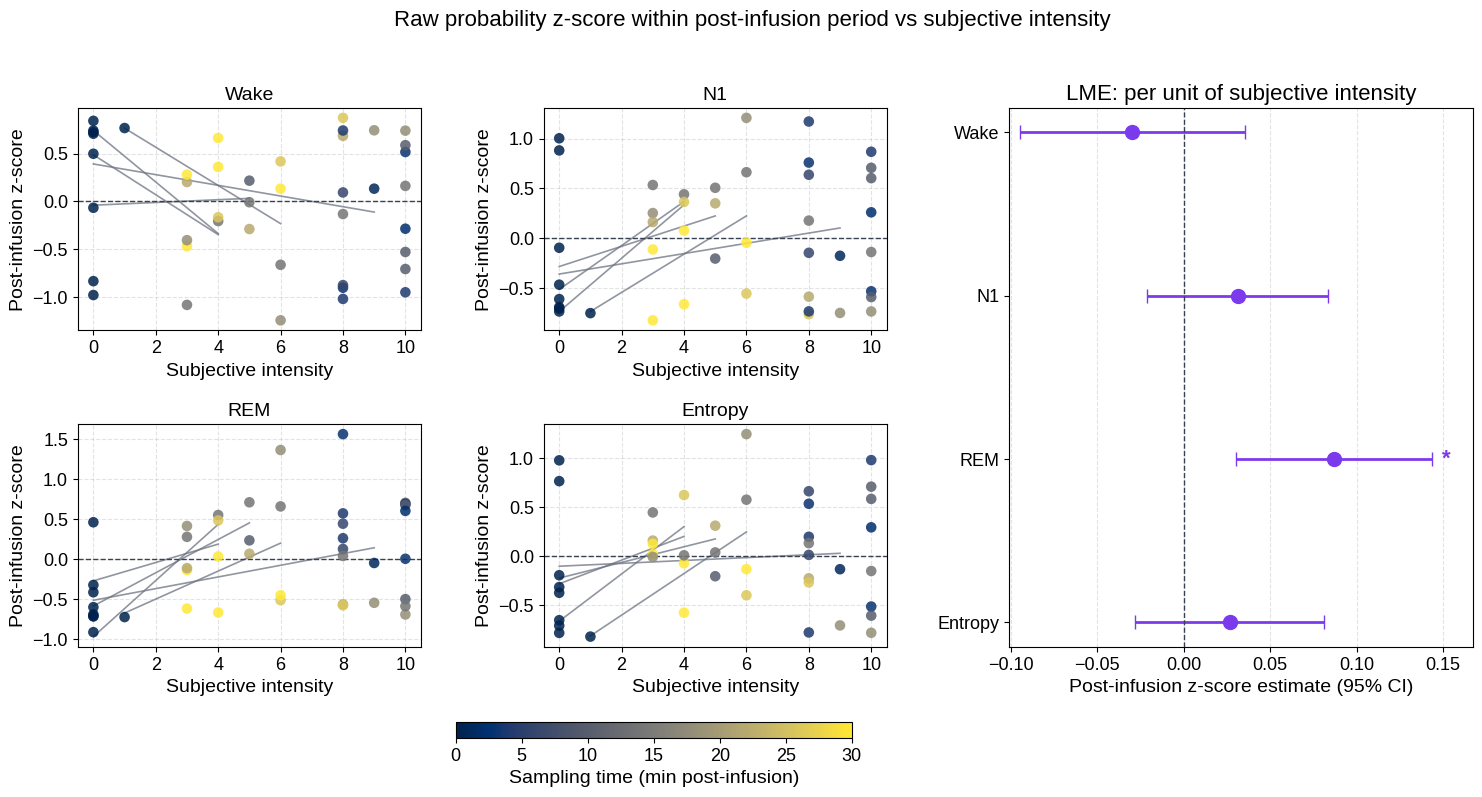

{'subjects with a within-subject trend line': ['P08',
  'P09',
  'P10',
  'P13',
  'P17']}

,subject,timepoint,intensity,response,value
129,P08,0,1.0,Entropy,-0.818120
135,P09,0,0.0,Entropy,-0.372274
138,P10,0,0.0,Entropy,-0.651417
142,P13,0,0.0,Entropy,-0.314446
149,P17,0,0.0,Entropy,-0.193901
...,...,...,...,...,...
5,P08,30,6.0,Wake,0.132570
8,P09,30,4.0,Wake,0.359717
12,P10,30,3.0,Wake,-0.469188
17,P13,30,3.0,Wake,0.279643


'Saved figure files to /home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/postinfusion_zscore_lme_analysis_gssc_v1/figures'

In [6]:
from matplotlib.colors import Normalize

intensity_points = intensity_rating_post_z.dropna(subset=list(RESPONSES)).melt(
    id_vars=['subject', 'timepoint', 'intensity'], value_vars=list(RESPONSES),
    var_name='response', value_name='value')
intensity_points['response'] = intensity_points['response'].map(RESPONSE_LABELS)

# Subjects with enough distinct ratings to show a within-subject trend line.
MIN_DISTINCT_INTENSITIES = 3
trend_subjects = sorted(
    subject for subject, group in intensity_rating_post_z.dropna(subset=list(RESPONSES)).groupby('subject')
    if group['intensity'].nunique() >= MIN_DISTINCT_INTENSITIES)

time_norm = Normalize(intensity_points['timepoint'].min(), intensity_points['timepoint'].max())
figure = plt.figure(figsize=(18, 7))
grid = figure.add_gridspec(2, 3, width_ratios=(1.0, 1.0, 1.35), wspace=0.32, hspace=0.42)
scatter_axes = [figure.add_subplot(grid[row, column]) for row in (0, 1) for column in (0, 1)]
for axis, response in zip(scatter_axes, response_order):
    panel = intensity_points.loc[intensity_points['response'].eq(response)]
    axis.scatter(panel['intensity'], panel['value'], c=panel['timepoint'], cmap='cividis', norm=time_norm, s=58, edgecolors='none', alpha=0.85, zorder=3)
    for subject in trend_subjects:
        subject_panel = panel.loc[panel['subject'].eq(subject)]
        if subject_panel['intensity'].nunique() < MIN_DISTINCT_INTENSITIES:
            continue
        slope, intercept = np.polyfit(subject_panel['intensity'], subject_panel['value'], 1)
        line_x = np.array([subject_panel['intensity'].min(), subject_panel['intensity'].max()])
        axis.plot(line_x, slope * line_x + intercept, color='#6b7280', linewidth=1.2, alpha=0.75, zorder=2)
    axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
    axis.set_title(response, fontsize=14)
    axis.set_xlabel('Subjective intensity')
    axis.set_ylabel('Post-infusion z-score')
    axis.grid(linestyle='--', alpha=0.35)
forest_axis = figure.add_subplot(grid[:, 2])
draw_post_z_forest(forest_axis, intensity_effects, 'LME: per unit of subjective intensity', 'Post-infusion z-score estimate (95% CI)', INTENSITY_COLOUR)
colour_axis = figure.add_axes([0.335, -0.02, 0.22, 0.022])
colour_bar = figure.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap='cividis'), cax=colour_axis, orientation='horizontal')
colour_bar.set_label('Sampling time (min post-infusion)')
figure.suptitle('Raw probability z-score within post-infusion period vs subjective intensity', fontsize=16, y=1.02)
for extension in ('png', 'svg', 'pdf'): figure.savefig(FIGURES_DIR / f'intensity_hypnodensities_and_lme_raw_probability_postinfusion_zscore.{extension}', dpi=300, bbox_inches='tight')
plt.show()
display({'subjects with a within-subject trend line': trend_subjects})
display(intensity_points.sort_values(['response', 'timepoint', 'subject']))
display(f'Saved figure files to {FIGURES_DIR}')


## 7. Entity post-infusion z-score figures

For visualization, z-scored electrode values are averaged over electrodes. The first panel summarizes each subject within entity state; the second retains every paired `subject × timepoint` rating. Both forest plots show the post-infusion-z-score LME coefficients directly.

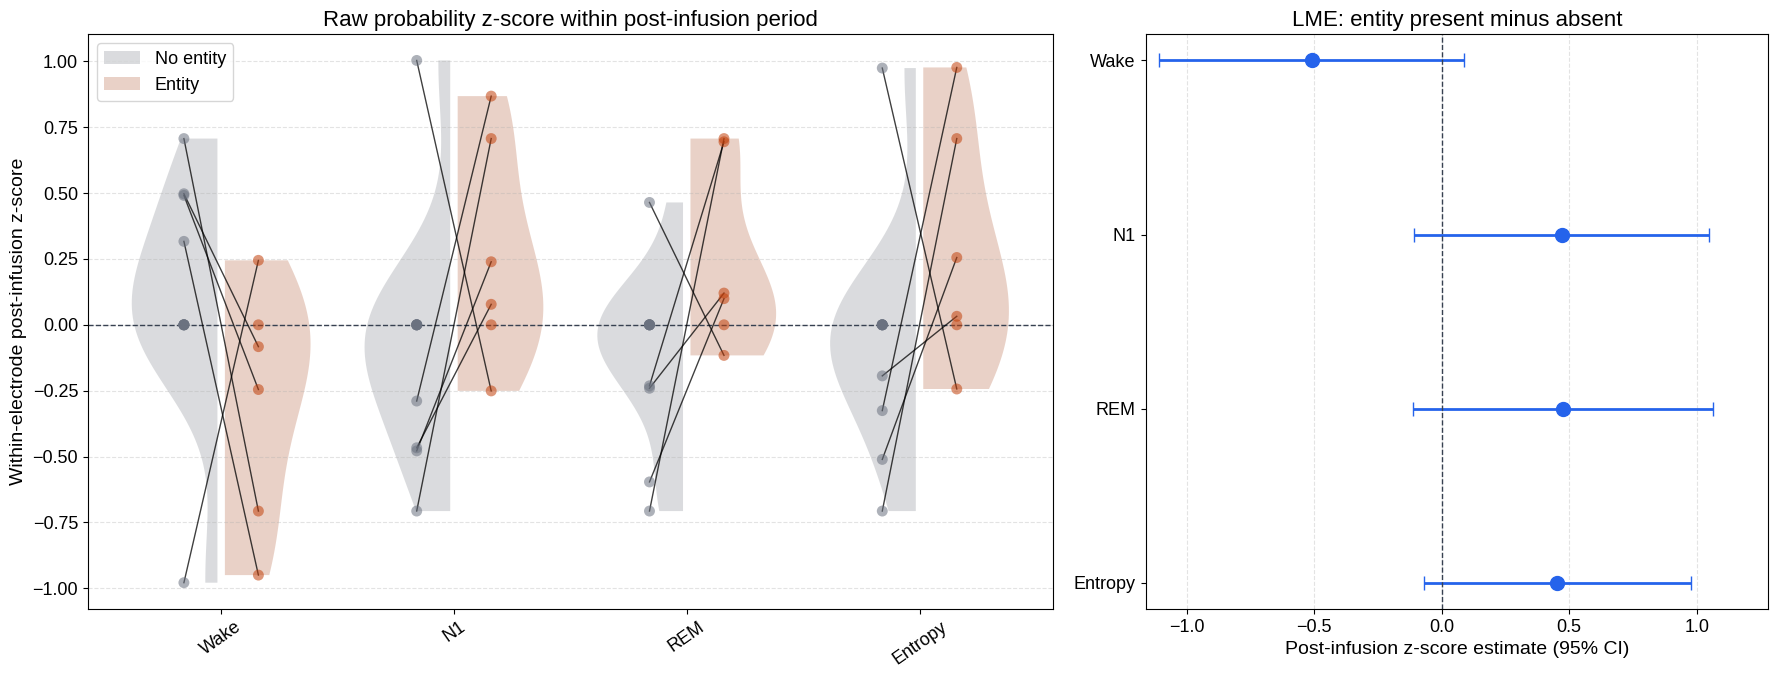

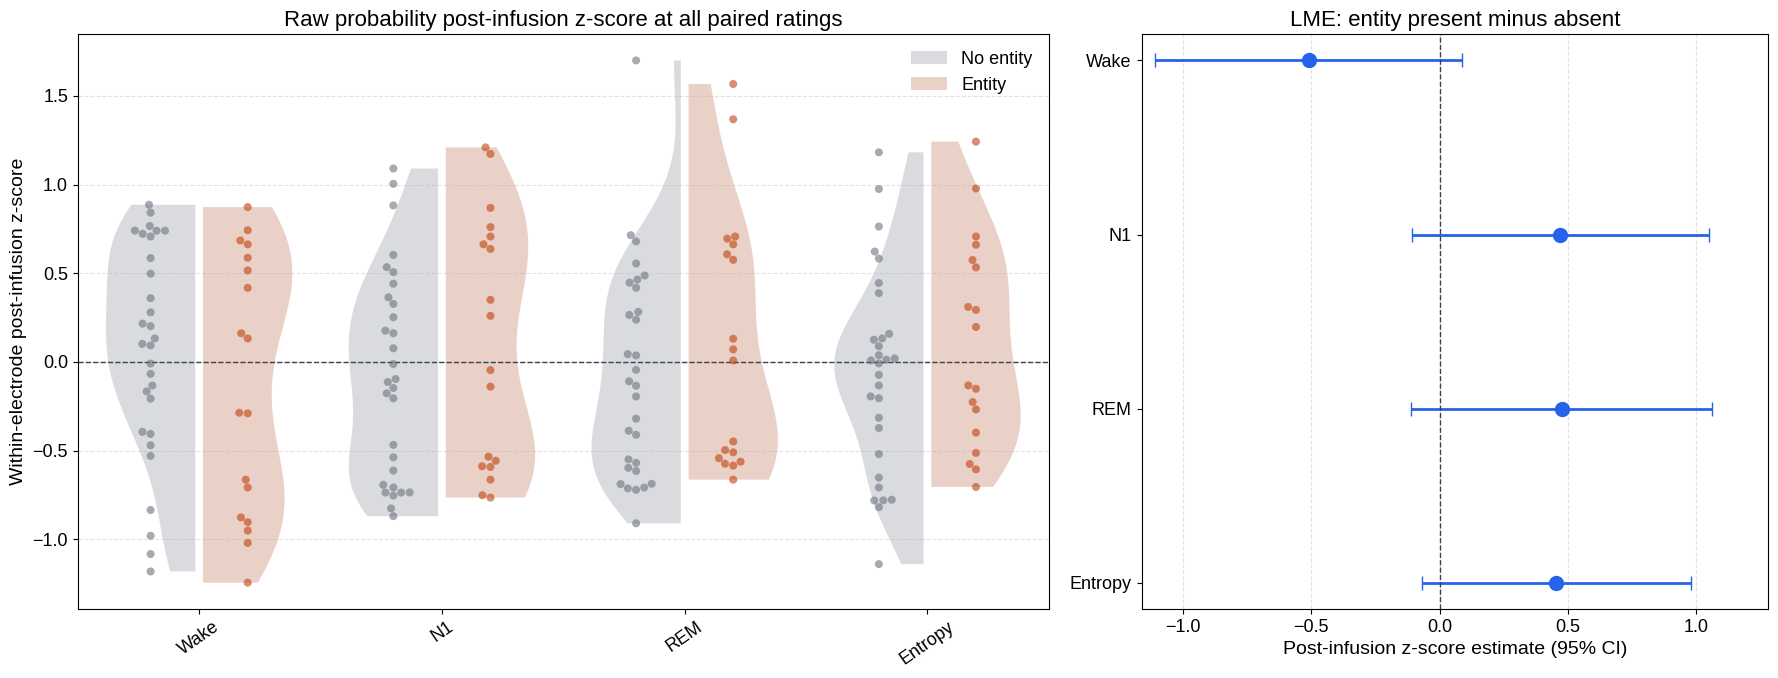

,subject,timepoint,entity,response,value,entity_label
144,P08,0,0,Entropy,-0.818120,No entity
145,P08,10,0,Entropy,-0.203951,No entity
150,P09,0,0,Entropy,-0.372274,No entity
151,P09,14,0,Entropy,0.444660,No entity
152,P09,30,0,Entropy,-0.072386,No entity
...,...,...,...,...,...,...
32,P22,4,1,Wake,-0.950211,Entity
36,P23,2,1,Wake,-0.285827,Entity
37,P23,3,1,Wake,0.515855,Entity
38,P23,10,1,Wake,0.587265,Entity


'Saved figure files to /home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/postinfusion_zscore_lme_analysis_gssc_v1/figures'

In [7]:
post_z_subject_state_means = (
    entity_rating_post_z.groupby(['subject', 'entity'], observed=True)[list(RESPONSES)].mean().reset_index()
)
post_z_plot_data = post_z_subject_state_means.melt(
    id_vars=['subject', 'entity'], value_vars=list(RESPONSES), var_name='response', value_name='value'
)
post_z_plot_data['response'] = post_z_plot_data['response'].map(RESPONSE_LABELS)
post_z_plot_data['entity_label'] = post_z_plot_data['entity'].map(ENTITY_LABELS)

figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(data=post_z_plot_data, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, split=True, inner=None, palette=palette, cut=0, density_norm='width', gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.25)
for response_position, response in enumerate(response_order):
    response_subset = post_z_plot_data.loc[post_z_plot_data['response'].eq(response)]
    paired = response_subset.pivot(index='subject', columns='entity_label', values='value').dropna(subset=entity_order, how='any')
    for _, paired_subject in paired.iterrows(): axis.plot([response_position + point_offsets[entity_order[0]], response_position + point_offsets[entity_order[1]]], [paired_subject[entity_order[0]], paired_subject[entity_order[1]]], color='black', linewidth=1, alpha=0.75, zorder=3)
    for entity_label in entity_order:
        values = response_subset.loc[response_subset['entity_label'].eq(entity_label), 'value']
        axis.scatter(np.full(len(values), response_position + point_offsets[entity_label]), values, s=62, color=palette[entity_label], edgecolor='none', alpha=0.55, zorder=4)
axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
axis.set(title='Raw probability z-score within post-infusion period', xlabel='', ylabel='Within-electrode post-infusion z-score')
axis.tick_params(axis='x', rotation=35); axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None: legend.set_title(None)
draw_post_z_forest(axes[1], entity_effects, 'LME: entity present minus absent', 'Post-infusion z-score estimate (95% CI)', ENTITY_COLOUR)
figure.tight_layout()
for extension in ('png', 'svg', 'pdf'): figure.savefig(FIGURES_DIR / f'entities_hypnodensities_by_state_and_lme_raw_probability_postinfusion_zscore.{extension}', dpi=300, bbox_inches='tight')
plt.show()

post_z_all_points = entity_rating_post_z.dropna(subset=list(RESPONSES)).melt(id_vars=['subject', 'timepoint', 'entity'], value_vars=list(RESPONSES), var_name='response', value_name='value')
post_z_all_points['response'] = post_z_all_points['response'].map(RESPONSE_LABELS); post_z_all_points['entity_label'] = post_z_all_points['entity'].map(ENTITY_LABELS)
figure, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': (1.55, 1)})
axis = axes[0]
sns.violinplot(data=post_z_all_points, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, split=True, inner=None, palette=palette, cut=0, density_norm='width', gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.25)
sns.swarmplot(data=post_z_all_points, x='response', y='value', hue='entity_label', order=response_order, hue_order=entity_order, dodge=True, palette=palette, size=5.8, alpha=0.60, edgecolor='none', linewidth=0, ax=axis)
axis.axhline(0, color='#374151', linewidth=1, linestyle='--')
axis.set(title='Raw probability post-infusion z-score at all paired ratings', xlabel='', ylabel='Within-electrode post-infusion z-score')
axis.tick_params(axis='x', rotation=35); axis.grid(axis='y', linestyle='--', alpha=0.35)
legend = axis.get_legend()
if legend is not None:
    handles, labels = axis.get_legend_handles_labels(); legend.remove(); axis.legend(handles[:2], labels[:2], title=None, frameon=False)
draw_post_z_forest(axes[1], entity_effects, 'LME: entity present minus absent', 'Post-infusion z-score estimate (95% CI)', ENTITY_COLOUR)
figure.tight_layout()
for extension in ('png', 'svg', 'pdf'): figure.savefig(FIGURES_DIR / f'entities_hypnodensities_all_rating_points_raw_probability_postinfusion_zscore.{extension}', dpi=300, bbox_inches='tight')
plt.show()
display(post_z_all_points.sort_values(['response', 'entity', 'subject', 'timepoint']))
display(f'Saved figure files to {FIGURES_DIR}')


## 8. Combined results table

The two families are reported side by side on the shared post-infusion z-score scale, both fitted on electrode-averaged ratings. FDR correction remains within-family.

The entity contrast is informative only in subjects who reported both states; `n_subjects_with_both_states` records how many those are.


In [8]:
combined_columns = ['analysis', 'response', 'term', 'beta', 'standard_error',
                    'ci95_low', 'ci95_high', 'z_value', 'p_value', 'p_fdr_bh',
                    'n_subjects', 'n_paired_ratings', 'converged']
combined_results = pd.concat([
    intensity_post_z_lme_results.assign(analysis='Subjective intensity'),
    entity_post_z_lme_results.assign(analysis='Entity presence'),
], ignore_index=True)[combined_columns]
combined_results.to_csv(OUTPUT_DIR / 'combined_postinfusion_zscore_lme_results.csv', index=False)
display(combined_results.round(4))

# The entity contrast is carried entirely by subjects reporting both states.
entity_state_counts = (entity_rating_post_z.dropna(subset=list(RESPONSES))
    .groupby('subject')['entity']
    .agg(n_ratings='count', n_entity=lambda s: int((s == 1).sum()),
         n_no_entity=lambda s: int((s == 0).sum())))
entity_state_counts['contributes_within_subject_contrast'] = (
    entity_state_counts['n_entity'].gt(0) & entity_state_counts['n_no_entity'].gt(0))
entity_state_counts.to_csv(OUTPUT_DIR / 'entity_within_subject_contrast_availability.csv')
display(entity_state_counts)
display({
    'entity subjects with both states':
        int(entity_state_counts['contributes_within_subject_contrast'].sum()),
    'entity subjects total': int(len(entity_state_counts)),
})
display(f'Saved tables and parquet files to {OUTPUT_DIR}')


,analysis,response,term,beta,standard_error,ci95_low,ci95_high,z_value,p_value,p_fdr_bh,n_subjects,n_paired_ratings,converged
0,Subjective intensity,Wake,Per unit of subjective intensity,-0.0298,0.0332,-0.0949,0.0352,-0.8990,0.3686,0.3686,11,43,True
1,Subjective intensity,N1,Per unit of subjective intensity,0.0311,0.0267,-0.0212,0.0835,1.1660,0.2436,0.3686,11,43,True
2,Subjective intensity,REM,Per unit of subjective intensity,0.0869,0.0288,0.0304,0.1434,3.0149,0.0026,0.0103,11,43,True
3,Subjective intensity,Entropy,Per unit of subjective intensity,0.0265,0.0279,-0.0283,0.0813,0.9483,0.3430,0.3686,11,43,True
4,Entity presence,Wake,Entity present minus absent,-0.5090,0.3049,-1.1066,0.0886,-1.6695,0.0950,0.1127,12,48,True
5,Entity presence,N1,Entity present minus absent,0.4707,0.2949,-0.1074,1.0487,1.5960,0.1105,0.1127,12,48,True
6,Entity presence,REM,Entity present minus absent,0.4754,0.2997,-0.1120,1.0627,1.5862,0.1127,0.1127,12,48,True
7,Entity presence,Entropy,Entity present minus absent,0.4541,0.2674,-0.0701,0.9782,1.6978,0.0895,0.1127,12,48,True


,n_ratings,n_entity,n_no_entity,contributes_within_subject_contrast
subject,,,,
P08,6,4,2,True
P09,3,0,3,False
P10,4,0,4,False
P13,5,0,5,False
P15,2,2,0,False
P17,7,6,1,True
P19,2,1,1,True
P21,2,0,2,False
P22,4,1,3,True


{'entity subjects with both states': 5, 'entity subjects total': 12}

'Saved tables and parquet files to /home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/postinfusion_zscore_lme_analysis_gssc_v1'